# Real Estate Price Regression with a NumPy MLP
**Sections 2–8** consolidated into a single, clean notebook.

Dataset: `new_house_transactions.csv`

Run cells top-to-bottom; adjust `DATA_PATH`, `CSV_FILE`, and `TARGET` as needed.

In [35]:

import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 6)
SEED = 123
rng = np.random.default_rng(SEED)

DATA_PATH = "train"
CSV_FILE  = "new_house_transactions.csv"
TARGET    = "price_new_house_transactions"


## 2. Dataset Explanation

Loaded: new_house_transactions.csv | shape=(5433, 11)


,month,sector,num_new_house_transactions,area_new_house_transactions,price_new_house_transactions,amount_new_house_transactions,area_per_unit_new_house_transactions,total_price_per_unit_new_house_transactions,num_new_house_available_for_sale,area_new_house_available_for_sale,period_new_house_sell_through
0,2019-Jan,sector 1,52,4906,28184,13827.14,94,265.91,159.0,15904.0,3.78
1,2019-Jan,sector 2,145,15933,17747,28277.73,110,195.02,1491.0,175113.0,12.29
2,2019-Jan,sector 4,6,725,28004,1424.21,127,356.05,40.0,6826.0,5.95
3,2019-Jan,sector 5,2,212,37432,792.10,106,396.05,161.0,17173.0,83.95
4,2019-Jan,sector 6,5,773,15992,607.94,95,151.99,189.0,19696.0,14.27


,column,dtype,kind,n_unique(categorical)
0,month,object,categorical,67.0
1,sector,object,categorical,95.0
2,num_new_house_transactions,int64,numeric,NaN
3,area_new_house_transactions,int64,numeric,NaN
4,price_new_house_transactions,int64,numeric,NaN
5,amount_new_house_transactions,float64,numeric,NaN
6,area_per_unit_new_house_transactions,int64,numeric,NaN
7,total_price_per_unit_new_house_transactions,float64,numeric,NaN
8,num_new_house_available_for_sale,float64,numeric,NaN
9,area_new_house_available_for_sale,float64,numeric,NaN


Numeric summary:


,num_new_house_transactions,area_new_house_transactions,price_new_house_transactions,amount_new_house_transactions,area_per_unit_new_house_transactions,total_price_per_unit_new_house_transactions,num_new_house_available_for_sale,area_new_house_available_for_sale,period_new_house_sell_through,month_dt,year,month_num
count,5433.000000,5433.000000,5433.000000,5433.000000,5433.000000,5433.000000,5419.000000,5.419000e+03,5419.000000,5433,5433.000000,5433.000000
mean,89.184428,9648.461992,43986.200810,32587.559558,128.622492,618.834116,1097.377191,1.271213e+05,21.765900,2021-10-12 04:38:49.762562048,2021.342168,6.268360
min,1.000000,24.000000,5114.000000,50.950000,24.000000,50.950000,1.000000,9.400000e+01,0.020000,2019-01-01 00:00:00,2019.000000,1.000000
25%,10.000000,1286.000000,22974.000000,5200.170000,100.000000,247.590000,179.000000,2.389400e+04,7.795000,2020-06-01 00:00:00,2020.000000,3.000000
50%,34.000000,4135.000000,39166.000000,16040.320000,112.000000,427.180000,558.000000,7.734500e+04,15.210000,2021-11-01 00:00:00,2021.000000,6.000000
75%,96.000000,10528.000000,56832.000000,38499.900000,135.000000,710.820000,1450.000000,1.727540e+05,26.615000,2023-03-01 00:00:00,2023.000000,9.000000
max,2669.000000,294430.000000,208288.000000,606407.640000,2003.000000,7803.600000,12048.000000,1.220617e+06,274.260000,2024-07-01 00:00:00,2024.000000,12.000000
std,161.724622,16691.548417,26488.972347,49047.627905,60.371473,628.762978,1589.671071,1.681336e+05,24.591511,NaN,1.622791,3.412183


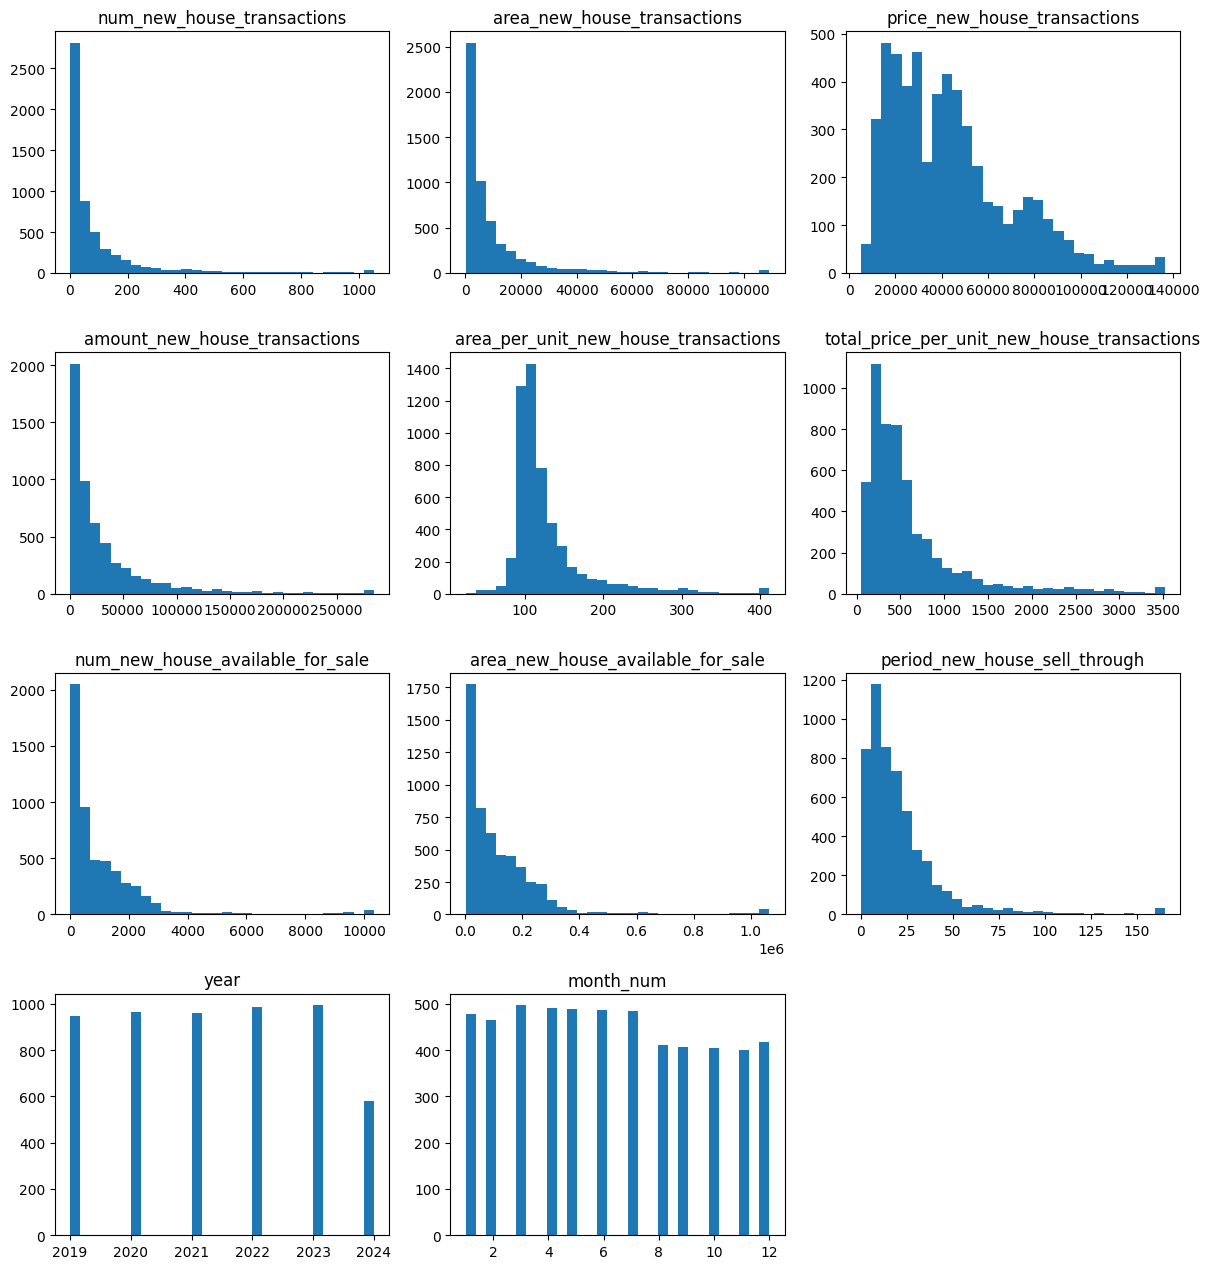

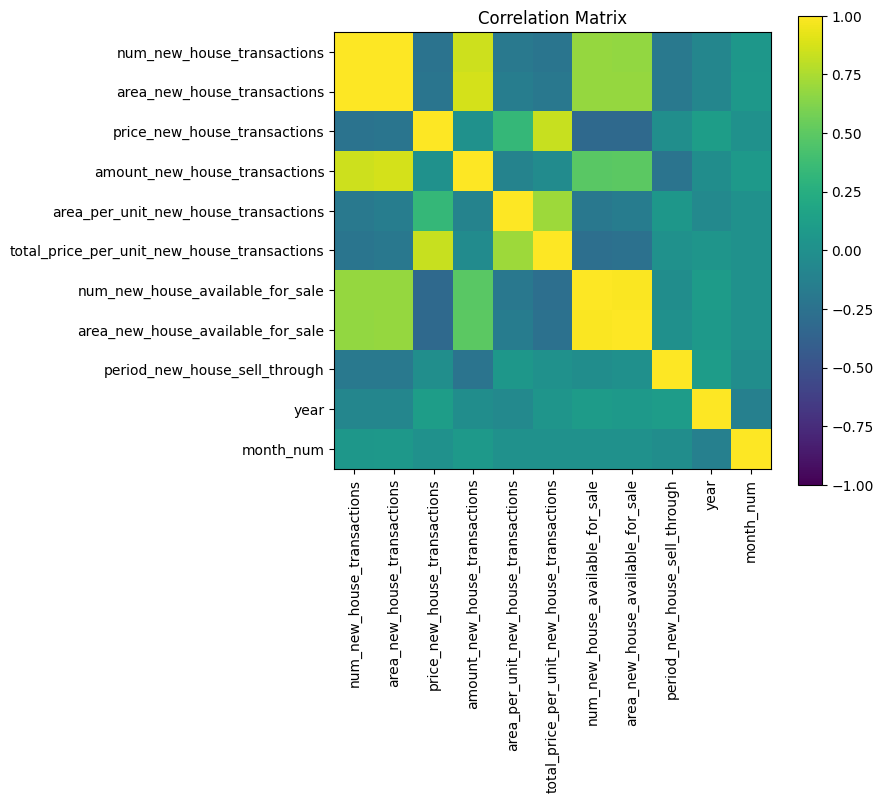

Report bullets:
- Rows: 5,433
- Numeric columns: 11
- Categorical columns: 2
- Suggested target: price_new_house_transactions (continuous)
- Temporal coverage (unique months): 67
- Geographic sectors: 95


In [36]:

df = pd.read_csv(os.path.join(DATA_PATH, CSV_FILE))
print(f"Loaded: {CSV_FILE} | shape={df.shape}")
display(df.head())

def feature_table(frame: pd.DataFrame):
    rows = []
    for col in frame.columns:
        dtype = str(frame[col].dtype)
        kind = "categorical" if frame[col].dtype == "object" else "numeric"
        rows.append((col, dtype, kind, frame[col].nunique() if kind=="categorical" else np.nan))
    return pd.DataFrame(rows, columns=["column","dtype","kind","n_unique(categorical)"])

display(feature_table(df))

if "month" in df.columns:
    try:
        df["month_dt"] = pd.to_datetime(df["month"], format="%Y-%b")
    except:
        df["month_dt"] = pd.to_datetime(df["month"], errors="coerce")
    df["year"] = df["month_dt"].dt.year
    df["month_num"] = df["month_dt"].dt.month

print("Numeric summary:"); display(df.describe())
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Histograms (clip top 0.5% to avoid unreadable long tails)
warnings.filterwarnings("ignore", category=FutureWarning)
if len(num_cols):
    ncols, nrows = 3, int(np.ceil(len(num_cols)/3))
    plt.figure(figsize=(4*ncols,3.2*nrows))
    for i,c in enumerate(num_cols,1):
        ax = plt.subplot(nrows,ncols,i)
        vals = df[c].dropna()
        if len(vals):
            vmax = np.quantile(vals, 0.995)
            ax.hist(vals.clip(upper=vmax), bins=30)
        ax.set_title(c)
    plt.tight_layout(); plt.show()

if len(num_cols) > 1:
    corr = df[num_cols].corr()
    plt.figure(figsize=(9,8))
    im = plt.imshow(corr, vmin=-1, vmax=1)
    plt.xticks(range(len(corr)), corr.columns, rotation=90)
    plt.yticks(range(len(corr)), corr.columns)
    plt.title("Correlation Matrix"); plt.colorbar(im); plt.tight_layout(); plt.show()

print("Report bullets:")
print(f"- Rows: {len(df):,}")
print(f"- Numeric columns: {len(df.select_dtypes(include=[np.number]).columns)}")
print(f"- Categorical columns: {len(df.select_dtypes(include='object').columns)}")
print(f"- Suggested target: {TARGET} (continuous)")
print(f"- Temporal coverage (unique months): {df['month'].nunique() if 'month' in df.columns else 'n/a'}")
print(f"- Geographic sectors: {df['sector'].nunique() if 'sector' in df.columns else 'n/a'}")


## 3. Data Cleaning and Normalization

In [37]:

df_raw = df.copy()

# Cyclical month
if "month_num" in df.columns:
    df["month_sin"] = np.sin(2*np.pi*(df["month_num"]-1)/12)
    df["month_cos"] = np.cos(2*np.pi*(df["month_num"]-1)/12)

# Drop duplicates
df = df.drop_duplicates()

# Impute
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include="object").columns.tolist()
impute_values = {}
for c in num_cols:
    if df[c].isna().any():
        impute_values[c] = float(df[c].median())
        df[c] = df[c].fillna(impute_values[c])
for c in cat_cols:
    if df[c].isna().any():
        mode = df[c].mode(dropna=True)
        impute_values[c] = mode.iloc[0] if not mode.empty else "missing"
        df[c] = df[c].fillna(impute_values[c])

# Winsorize numeric via IQR clipping
def winsorize_iqr(series, k=1.5):
    s = series.copy()
    q1,q3 = np.percentile(s.dropna(), [25,75])
    iqr = q3-q1
    low, high = q1 - k*iqr, q3 + k*iqr
    return s.clip(lower=low, upper=high), low, high

clip_bounds = {}
df_wins = df.copy()
for c in num_cols:
    df_wins[c], low, high = winsorize_iqr(df_wins[c])
    clip_bounds[c] = (low, high)

# One-hot encode categorical
df_enc = pd.get_dummies(df_wins, columns=cat_cols, drop_first=True)

# Standardize continuous features
# ----- Robust standardization of continuous features -----
# Build candidate continuous columns from the pre-encoded numeric frame
orig_cont_candidates = df_wins.select_dtypes(include=[np.number]).columns.tolist()

# Keep only those that actually exist in df_enc (after get_dummies)
cont_cols = [c for c in orig_cont_candidates if c in df_enc.columns]

# Add cyclical encodings if present
for cyc in ["month_sin", "month_cos"]:
    if cyc in df_enc.columns and cyc not in cont_cols:
        cont_cols.append(cyc)

# (Optional) drop columns you know you won't standardize (e.g., target, counts you want untouched)
if TARGET in cont_cols:
    cont_cols.remove(TARGET)
# If you plan to drop month_num later and rely on sin/cos only, don't standardize month_num:
if "month_num" in cont_cols:
    cont_cols.remove("month_num")

# Sanity checks / debug prints (you can keep or remove)
missing_in_enc = [c for c in cont_cols if c not in df_enc.columns]
dups = [c for c in set(cont_cols) if cont_cols.count(c) > 1]
print(f"Standardizing {len(cont_cols)} continuous cols. Missing in df_enc: {missing_in_enc}. Duplicates: {dups}")

# Compute stats on df_enc[cont_cols]
means = df_enc[cont_cols].mean()
stds  = df_enc[cont_cols].std(ddof=0).replace(0, 1.0)

# Perform column-wise assignment to avoid shape/key-length mismatch
df_norm = df_enc.copy()
for c in cont_cols:
    df_norm[c] = (df_norm[c] - means[c]) / stds[c]

# Temporal split
def temporal_split(frame, time_col="month_dt", ratios=(0.7,0.15,0.15)):
    if time_col in frame.columns and pd.api.types.is_datetime64_any_dtype(frame[time_col]):
        f = frame.sort_values(time_col).reset_index(drop=True)
    else:
        f = frame.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
    n = len(f); n_tr = int(ratios[0]*n); n_va = int(ratios[1]*n)
    return f.iloc[:n_tr], f.iloc[n_tr:n_tr+n_va], f.iloc[n_tr+n_va:]

df_norm["_time"] = df.get("month_dt")
train_df, val_df, test_df = temporal_split(df_norm, time_col="_time")

# Build X/y (numeric only), drop helper/time cols
drop_always = [TARGET, "month", "month_dt", "_time"]
def make_X_y(frame):
    f = frame.drop(columns=[c for c in drop_always if c in frame.columns], errors="ignore")
    X = f.select_dtypes(include=[np.number]).copy()
    if "month_num" in X.columns: X = X.drop(columns=["month_num"])
    y = frame[TARGET].astype(float).values
    return X, y

X_train, y_train = make_X_y(train_df)
X_val,   y_val   = make_X_y(val_df)
X_test,  y_test  = make_X_y(test_df)

X_train_np, X_val_np, X_test_np = X_train.values.astype(float), X_val.values.astype(float), X_test.values.astype(float)
print("Split sizes:", len(X_train_np), len(X_val_np), len(X_test_np))

# Target standardization
y_mu = y_train.mean()
y_sigma = y_train.std() if y_train.std() != 0 else 1.0
y_train_z = (y_train - y_mu) / y_sigma
y_val_z   = (y_val   - y_mu) / y_sigma
y_test_z  = (y_test  - y_mu) / y_sigma


Standardizing 11 continuous cols. Missing in df_enc: []. Duplicates: []
Split sizes: 3803 814 816


## 4. MLP Implementation (NumPy)

In [38]:

def relu(x):  return np.maximum(0.0, x)
def drelu(x): return (x > 0).astype(x.dtype)
def tanh(x):  return np.tanh(x)
def dtanh(x): return 1.0 - np.tanh(x)**2
ACT = {"relu": (relu, drelu), "tanh": (tanh, dtanh)}

class MLPRegressor:
    def __init__(self, input_dim, hidden_layers=[64,32], activation="relu", l2=1e-4, seed=SEED):
        self.sizes = [input_dim] + list(hidden_layers) + [1]
        self.activation = activation
        self.l2 = float(l2)
        self.rng = np.random.default_rng(seed)
        self.params = {}
        for i in range(len(self.sizes)-1):
            fan_in, fan_out = self.sizes[i], self.sizes[i+1]
            scale = math.sqrt(2.0/fan_in) if activation=="relu" and i < len(self.sizes)-2 else math.sqrt(1.0/fan_in)
            self.params[f"W{i}"] = self.rng.normal(0.0, scale, size=(fan_in, fan_out))
            self.params[f"b{i}"] = np.zeros((1, fan_out))

    def forward(self, X):
        cache = {"A0": X}
        f, df = ACT[self.activation]
        for i in range(len(self.sizes)-2):
            Z = cache[f"A{i}"] @ self.params[f"W{i}"] + self.params[f"b{i}"]
            A = f(Z); cache[f"Z{i+1}"]=Z; cache[f"A{i+1}"]=A
        Lm1 = len(self.sizes)-2
        ZL = cache[f"A{Lm1}"] @ self.params[f"W{Lm1}"] + self.params[f"b{Lm1}"]
        cache[f"Z{Lm1+1}"]=ZL; cache[f"A{Lm1+1}"]=ZL
        return ZL, cache

    def loss(self, y_hat, y_true):
        n = y_true.shape[0]
        mse = np.mean((y_hat - y_true)**2)
        if self.l2>0:
            reg = sum((self.params[f"W{i}"]**2).sum() for i in range(len(self.sizes)-1))
            mse += self.l2*reg/n
        return mse

    def backward(self, cache, y_true):
        grads = {}
        f, df = ACT[self.activation]
        L = len(self.sizes)-1
        n = y_true.shape[0]
        y_hat = cache[f"A{L}"]
        dZ = (2.0/n)*(y_hat - y_true)
        grads[f"dW{L-1}"] = cache[f"A{L-1}"].T @ dZ + (self.l2/n)*self.params[f"W{L-1}"]
        grads[f"db{L-1}"] = dZ.sum(0, keepdims=True)
        for i in reversed(range(L-1)):
            dA = dZ @ self.params[f"W{i+1}"].T
            Z = cache[f"Z{i+1}"]
            dZ = dA * df(Z)
            grads[f"dW{i}"] = cache[f"A{i}"].T @ dZ + (self.l2/n)*self.params[f"W{i}"]
            grads[f"db{i}"] = dZ.sum(0, keepdims=True)
        return grads

    def fit(self, X, y, X_val=None, y_val=None, epochs=300, batch_size=128, lr=3e-3, momentum=0.9, patience=30, verbose=1, seed=SEED):
        y = y.reshape(-1,1).astype(float)
        y_val = None if y_val is None else y_val.reshape(-1,1).astype(float)
        vW = {f"W{i}": np.zeros_like(self.params[f"W{i}"]) for i in range(len(self.sizes)-1)}
        vB = {f"b{i}": np.zeros_like(self.params[f"b{i}"]) for i in range(len(self.sizes)-1)}
        history = {"train_loss": [], "val_loss": []}
        best = {"val": np.inf, "params": None, "epoch": -1}
        def iter_minibatches(X, y, bs, seed):
            idx = np.arange(X.shape[0]); np.random.default_rng(seed).shuffle(idx)
            for s in range(0, len(idx), bs):
                b = idx[s:s+bs]; yield X[b], y[b]
        for epoch in range(1, epochs+1):
            for Xb, yb in iter_minibatches(X, y, batch_size, seed+epoch):
                y_hat, cache = self.forward(Xb)
                grads = self.backward(cache, yb)
                for i in range(len(self.sizes)-1):
                    vW[f"W{i}"] = momentum*vW[f"W{i}"] + (1-momentum)*grads[f"dW{i}"]
                    vB[f"b{i}"] = momentum*vB[f"b{i}"] + (1-momentum)*grads[f"db{i}"]
                    self.params[f"W{i}"] -= lr * vW[f"W{i}"]
                    self.params[f"b{i}"] -= lr * vB[f"b{i}"]
            tr_hat,_ = self.forward(X); tr_loss = self.loss(tr_hat, y); history["train_loss"].append(tr_loss)
            if X_val is not None and y_val is not None:
                va_hat,_ = self.forward(X_val); va_loss = self.loss(va_hat, y_val); history["val_loss"].append(va_loss)
                if va_loss < best["val"] - 1e-6:
                    best = {"val": va_loss, "params": {k:v.copy() for k,v in self.params.items()}, "epoch": epoch}
                elif epoch - best["epoch"] >= patience:
                    if best["params"] is not None: self.params = best["params"]
                    if verbose: print(f"Early stopping at epoch {epoch} (best @ {best['epoch']}, val={best['val']:.6f})")
                    break
            if verbose and (epoch % 10 == 0 or epoch == 1):
                print(f"Epoch {epoch:4d} | train MSE {tr_loss:.6f}" + (f" | val MSE {va_loss:.6f}" if X_val is not None else ""))
        return history

    def predict(self, X):
        y_hat,_ = self.forward(X)
        return y_hat.ravel()


## 5. Model Training

Epoch    1 | train MSE 0.895231 | val MSE 1.200400
Epoch   10 | train MSE 0.237888 | val MSE 0.354876
Epoch   20 | train MSE 0.139792 | val MSE 0.200596
Epoch   30 | train MSE 0.113492 | val MSE 0.152785
Epoch   40 | train MSE 0.100272 | val MSE 0.124830
Epoch   50 | train MSE 0.092071 | val MSE 0.109068
Epoch   60 | train MSE 0.085813 | val MSE 0.100409
Epoch   70 | train MSE 0.081317 | val MSE 0.092209
Epoch   80 | train MSE 0.077861 | val MSE 0.087344
Epoch   90 | train MSE 0.075022 | val MSE 0.082281
Epoch  100 | train MSE 0.072739 | val MSE 0.078824
Epoch  110 | train MSE 0.071034 | val MSE 0.077106
Epoch  120 | train MSE 0.069476 | val MSE 0.072123
Epoch  130 | train MSE 0.067854 | val MSE 0.071484
Epoch  140 | train MSE 0.066642 | val MSE 0.069332
Epoch  150 | train MSE 0.065555 | val MSE 0.067898
Epoch  160 | train MSE 0.064686 | val MSE 0.067348
Epoch  170 | train MSE 0.063684 | val MSE 0.065418
Epoch  180 | train MSE 0.062861 | val MSE 0.064034
Epoch  190 | train MSE 0.062187

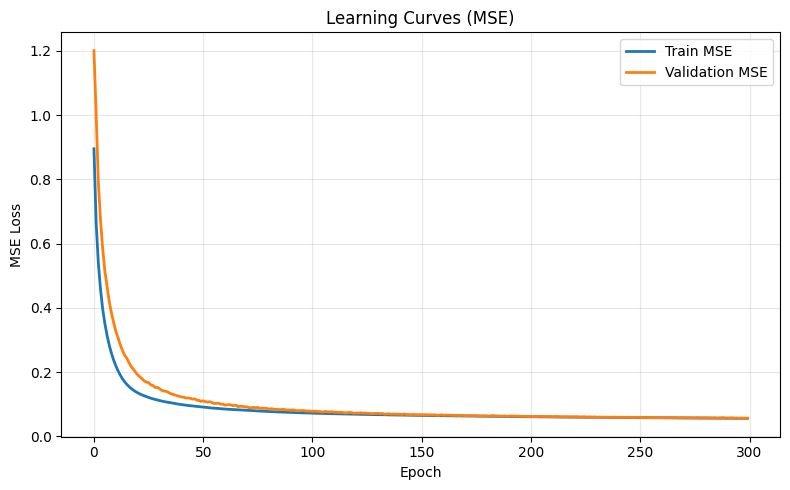

Train  -> RMSE: 5699.84 | MAE: 3342.36 | R^2: 0.9436
Val    -> RMSE: 5724.54 | MAE: 4158.19 | R^2: 0.9566
Test   -> RMSE: 6689.57 | MAE: 4960.70 | R^2: 0.9399


In [39]:

input_dim = X_train_np.shape[1]
mlp = MLPRegressor(input_dim=input_dim, hidden_layers=[64,32], activation="relu", l2=1e-4, seed=SEED)

history = mlp.fit(
    X_train_np, y_train_z,
    X_val=X_val_np, y_val=y_val_z,
    epochs=300, batch_size=128, lr=3e-3, momentum=0.9, patience=30, verbose=1, seed=SEED
)

# Learning curves
plt.figure(figsize=(8,5))
plt.plot(history["train_loss"], label="Train MSE", linewidth=2)
plt.plot(history["val_loss"], label="Validation MSE", linewidth=2)
plt.xlabel("Epoch"); plt.ylabel("MSE Loss"); plt.title("Learning Curves (MSE)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

def denorm(yz): return yz * y_sigma + y_mu
def rmse(y, yhat): return np.sqrt(np.mean((y - yhat)**2))
def mae(y, yhat):  return np.mean(np.abs(y - yhat))
def r2(y, yhat):   return 1 - np.sum((y - yhat)**2) / np.sum((y - y.mean())**2)
def mape(y, yhat): return np.mean(np.abs((y - yhat) / y)) * 100

yhat_tr = denorm(mlp.predict(X_train_np))
yhat_va = denorm(mlp.predict(X_val_np))
yhat_te = denorm(mlp.predict(X_test_np))

print("Train  -> RMSE: %.2f | MAE: %.2f | R^2: %.4f" % (rmse(y_train, yhat_tr), mae(y_train, yhat_tr), r2(y_train, yhat_tr)))
print("Val    -> RMSE: %.2f | MAE: %.2f | R^2: %.4f" % (rmse(y_val,   yhat_va), mae(y_val,   yhat_va), r2(y_val,   yhat_va)))
print("Test   -> RMSE: %.2f | MAE: %.2f | R^2: %.4f" % (rmse(y_test,  yhat_te), mae(y_test,  yhat_te), r2(y_test,  yhat_te)))


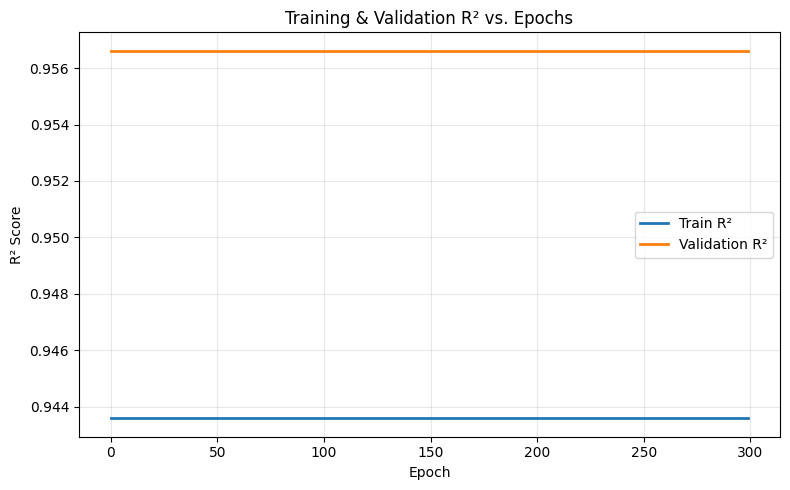

In [40]:
# === R² vs Epochs (Regression Accuracy) ===

train_r2_scores = []
val_r2_scores = []

for ep in range(len(history["train_loss"])):
    # predict using current weights
    yhat_train_ep = mlp.predict(X_train_np)  # already z-scaled output expected
    yhat_val_ep   = mlp.predict(X_val_np)

    # denormalize to compute R² correctly
    yhat_train_ep_denorm = (yhat_train_ep * y_sigma) + y_mu
    yhat_val_ep_denorm   = (yhat_val_ep * y_sigma) + y_mu

    # compute R²
    train_r2_scores.append(1 - np.sum((y_train - yhat_train_ep_denorm)**2) / np.sum((y_train - np.mean(y_train))**2))
    val_r2_scores.append(1 - np.sum((y_val - yhat_val_ep_denorm)**2) / np.sum((y_val - np.mean(y_val))**2))

plt.figure(figsize=(8,5))
plt.plot(train_r2_scores, label="Train R²", linewidth=2)
plt.plot(val_r2_scores, label="Validation R²", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("R² Score")
plt.title("Training & Validation R² vs. Epochs")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 6. Training & Testing Strategy (diagnostics)

In [41]:

print("Train date range:", train_df["_time"].min(), "→", train_df["_time"].max())
print("Val date range:  ", val_df["_time"].min(), "→", val_df["_time"].max())
print("Test date range: ", test_df["_time"].min(), "→", test_df["_time"].max())


Train date range: 2019-01-01 00:00:00 → 2022-12-01 00:00:00
Val date range:   2022-12-01 00:00:00 → 2023-10-01 00:00:00
Test date range:  2023-10-01 00:00:00 → 2024-07-01 00:00:00


## 7–8. Error Curves, Residuals, Metrics & Baseline

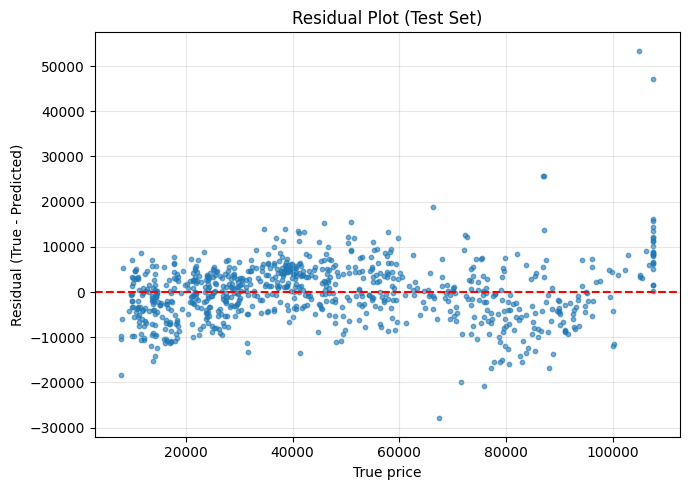

,Split,RMSE,MAE,MAPE (%),R^2
0,Train,5699.836045,3342.361223,9.456429,0.943595
1,Validation,5724.541570,4158.192724,12.371699,0.956613
2,Test,6689.573192,4960.702327,15.258389,0.939908



Baseline (mean predictor)
RMSE: 27614.28 | MAE: 22495.73 | R^2: -0.0240


In [42]:

# Residuals
residuals = y_test - yhat_te
plt.figure(figsize=(7,5))
plt.scatter(y_test, residuals, s=10, alpha=0.6)
plt.axhline(0, linestyle="--", color="red")
plt.xlabel("True price"); plt.ylabel("Residual (True - Predicted)")
plt.title("Residual Plot (Test Set)"); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

# Metrics table
results_df = pd.DataFrame({
    "Split": ["Train","Validation","Test"],
    "RMSE": [rmse(y_train, yhat_tr), rmse(y_val, yhat_va), rmse(y_test, yhat_te)],
    "MAE":  [mae(y_train, yhat_tr),  mae(y_val, yhat_va),  mae(y_test, yhat_te)],
    "MAPE (%)": [mape(y_train, yhat_tr), mape(y_val, yhat_va), mape(y_test, yhat_te)],
    "R^2":  [r2(y_train, yhat_tr),   r2(y_val, yhat_va),   r2(y_test, yhat_te)]
})
display(results_df)

# Baseline
baseline_pred = np.full_like(y_test, y_train.mean())
baseline_rmse = rmse(y_test, baseline_pred)
baseline_mae  = mae(y_test, baseline_pred)
baseline_r2   = r2(y_test, baseline_pred)

print("\nBaseline (mean predictor)")
print(f"RMSE: {baseline_rmse:.2f} | MAE: {baseline_mae:.2f} | R^2: {baseline_r2:.4f}")
